In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/sensors.csv", index_col="timestamp", parse_dates=True)
df

,PMP-01,MTR-03,TR-114
timestamp,,,
2026-01-01 00:00:00,64.780,2.334,55.076
2026-01-01 00:01:00,65.491,2.228,55.047
2026-01-01 00:02:00,67.325,2.686,54.842
2026-01-01 00:03:00,63.389,1.904,56.203
2026-01-01 00:04:00,64.949,2.032,54.924
...,...,...,...
2026-01-30 23:55:00,64.695,2.581,53.423
2026-01-30 23:56:00,65.317,2.131,54.239
2026-01-30 23:57:00,65.188,1.651,55.102


<Axes: title={'center': 'TR-114, one day'}, xlabel='timestamp'>

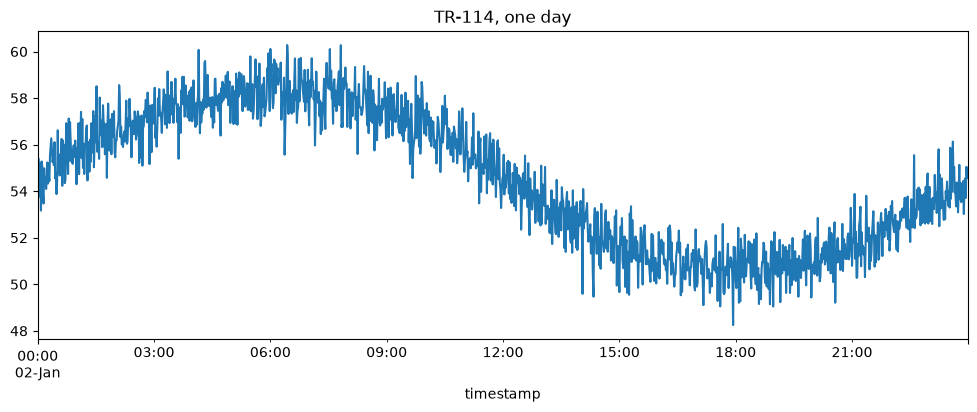

In [2]:
df.loc["2026-01-02", "TR-114"].plot(figsize=(12, 4), title="TR-114, one day")

<Axes: title={'center': 'TR-114, one month'}, xlabel='timestamp'>

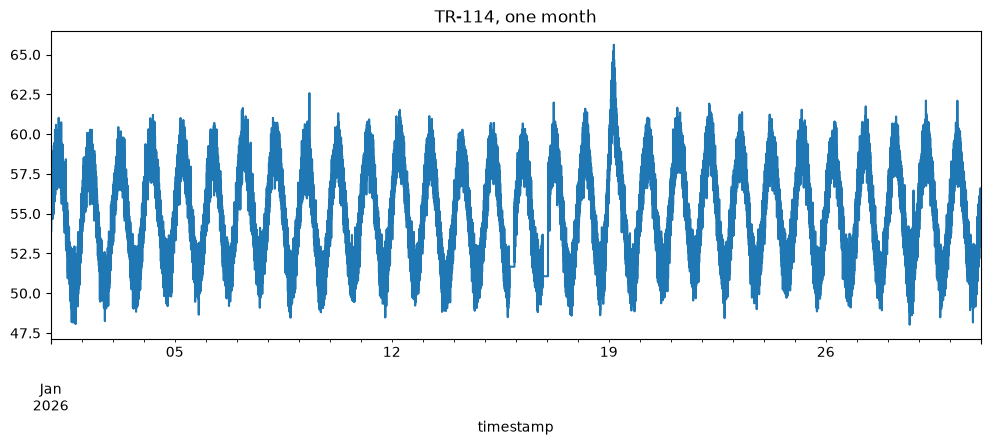

In [3]:

df.loc["2026-01", "TR-114"].plot(figsize=(12, 4), title="TR-114, one month")

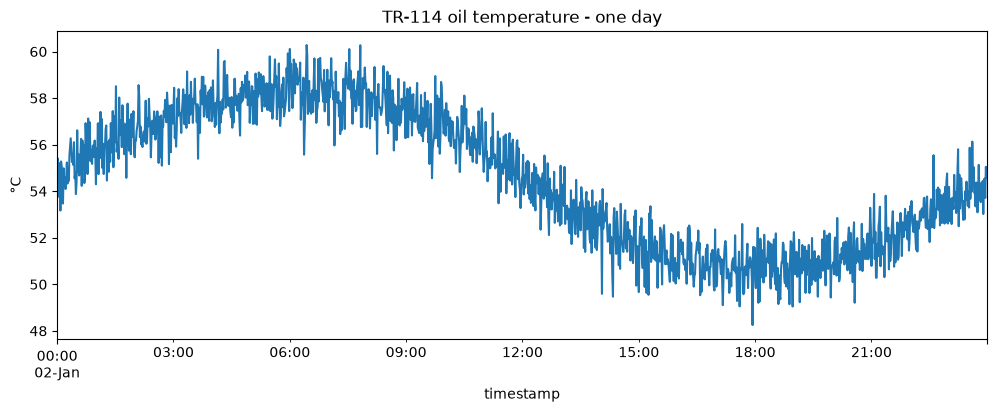

In [4]:
ROOT  = Path.cwd().parent
RESULTS = ROOT / "results"

ax = df.loc["2026-01-02", "TR-114"].plot(figsize=(12, 4), title="TR-114 oil temperature - one day")
ax.set_ylabel("°C")
ax.figure.savefig(RESULTS / "baseline_tr114_day.png", dpi=150, bbox_inches="tight")

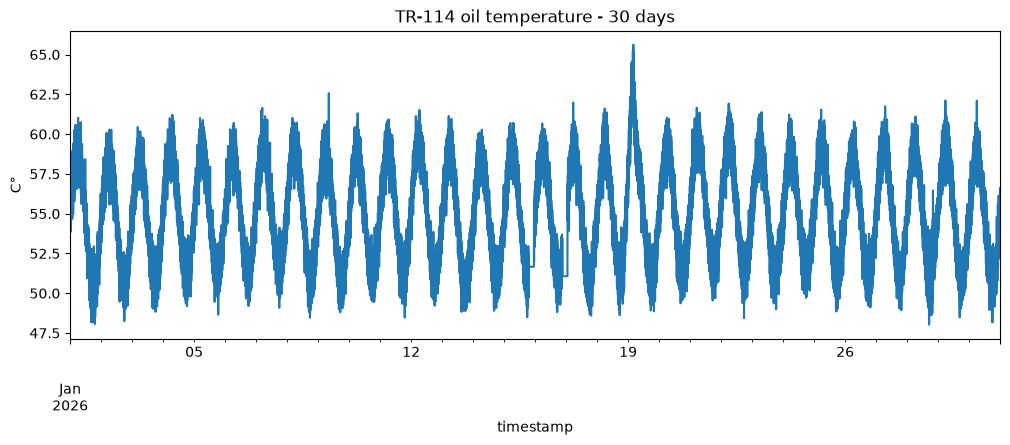

In [5]:
ax = df.loc["2026-01", "TR-114"].plot(figsize=(12, 4), title="TR-114 oil temperature - 30 days")
ax.set_ylabel("C°")
ax.figure.savefig(RESULTS / "baseline_tr114_month.png", dpi=150, bbox_inches="tight")

In [6]:


import yaml

ROOT = Path.cwd().parent

with open(ROOT / "config.yaml", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)
units = {s["id"]: s["unit"] for s in cfg["data"]["sensors"]}

df = pd.read_csv(ROOT / "data" / "sensors.csv",
                 index_col="timestamp", parse_dates=True)
faults = pd.read_csv(ROOT / "data" / "faults.csv",
                     parse_dates=["start", "end"])


def plot_fault(fault, pad, suffix):
    sensor = fault["sensor_id"]
    window = df.loc[fault["start"] - pad : fault["end"] + pad, sensor]

    ax = window.plot(
        figsize=(12, 4),
        title=f'{fault["fault_id"]} {fault["fault_type"]} — {sensor}',
    )
    ax.set_ylabel(units[sensor])
    ax.axvspan(fault["start"], fault["end"], color="red", alpha=0.15)

    ax.figure.savefig(
        ROOT / "results" / f'fault_{fault["fault_id"]}_{suffix}.png',
        dpi=150, bbox_inches="tight",
    )
    plt.close(ax.figure)


for _, f in faults.iterrows():
    is_spike = f["fault_type"] == "spike"

    plot_fault(f, pd.Timedelta(hours=12) if is_spike else pd.Timedelta(days=4), "wide")
    plot_fault(f, pd.Timedelta(minutes=30) if is_spike else pd.Timedelta(hours=2), "close")